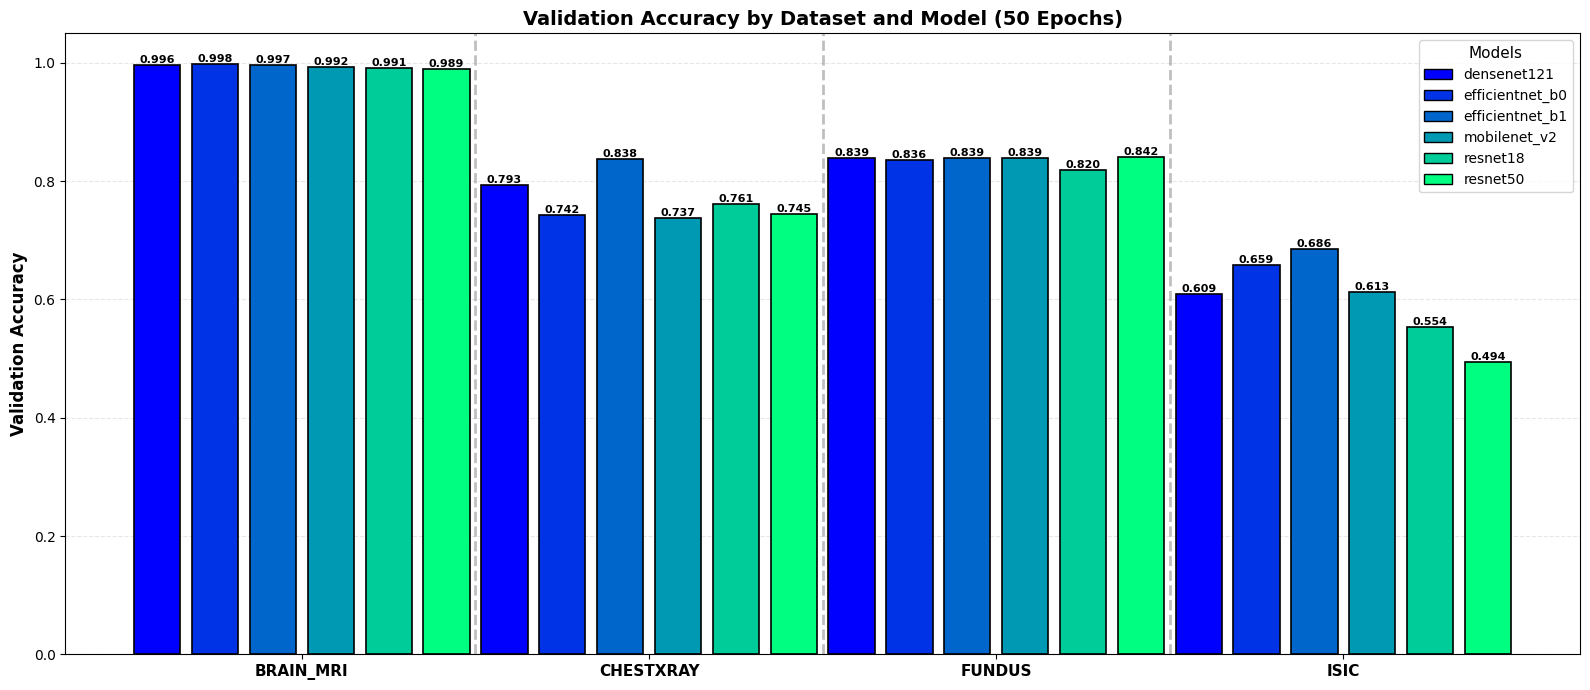


Validation Accuracy Summary by Dataset:

BRAIN_MRI:
  densenet121         : 0.9957
  efficientnet_b0     : 0.9985
  efficientnet_b1     : 0.9972
  mobilenet_v2        : 0.9923
  resnet18            : 0.9908
  resnet50            : 0.9889

CHESTXRAY:
  densenet121         : 0.7933
  efficientnet_b0     : 0.7420
  efficientnet_b1     : 0.8381
  mobilenet_v2        : 0.7372
  resnet18            : 0.7612
  resnet50            : 0.7452

FUNDUS:
  densenet121         : 0.8388
  efficientnet_b0     : 0.8361
  efficientnet_b1     : 0.8388
  mobilenet_v2        : 0.8388
  resnet18            : 0.8197
  resnet50            : 0.8415

ISIC:
  densenet121         : 0.6092
  efficientnet_b0     : 0.6590
  efficientnet_b1     : 0.6858
  mobilenet_v2        : 0.6130
  resnet18            : 0.5536
  resnet50            : 0.4943


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Define the data structure
datasets = ['brain_mri', 'chestxray', 'fundus', 'isic']
models = ['densenet121', 'efficientnet_b0', 'efficientnet_b1', 'mobilenet_v2', 'resnet18', 'resnet50']

# Validation accuracy data for all combinations (collected from metrics.json)
val_accuracy_data = {
    'brain_mri': [0.9956909818405664, 0.9984610649430594, 0.997229916897507, 0.992305324715297, 0.9907663896583564, 0.9889196675900277],
    'chestxray': [0.7932692307692307, 0.7419871794871795, 0.8381410256410257, 0.7371794871794872, 0.7612179487179487, 0.7451923076923077],
    'fundus': [0.8387978142076503, 0.8360655737704918, 0.8387978142076503, 0.8387978142076503, 0.819672131147541, 0.8415300546448088],
    'isic': [0.6091954022988506, 0.6590038314176245, 0.685823754789272, 0.6130268199233716, 0.553639846743295, 0.4942528735632184]
}

# Create a list for plotting
plot_data = []
x_labels = []
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

for dataset_idx, dataset in enumerate(datasets):
    for model_idx, model in enumerate(models):
        plot_data.append(val_accuracy_data[dataset][model_idx])
        x_labels.append(model)

# Create figure
fig, ax = plt.subplots(figsize=(16, 7))

# Create bar positions
x_positions = np.arange(len(plot_data))
bar_width = 0.8

# Create bars with color coding by model
model_colors = []
for i in range(len(plot_data)):
    model_idx = i % len(models)
    model_colors.append(colors[model_idx])

bars = ax.bar(x_positions, plot_data, bar_width, color=model_colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, plot_data)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')

# Customize plot
ax.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Validation Accuracy by Dataset and Model (50 Epochs)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.05)

# Set x-axis ticks and labels
dataset_positions = []
dataset_labels = []
for i in range(len(datasets)):
    start_pos = i * len(models)
    end_pos = start_pos + len(models) - 1
    middle_pos = (start_pos + end_pos) / 2
    dataset_positions.append(middle_pos)
    dataset_labels.append(datasets[i].upper())

ax.set_xticks(dataset_positions)
ax.set_xticklabels(dataset_labels, fontsize=11, fontweight='bold')

# Add grid for better readability
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Create legend for models
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=models[i]) 
                   for i in range(len(models))]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, title='Models', title_fontsize=11)

# Add vertical separators between datasets
for i in range(1, len(datasets)):
    sep_x = i * len(models) - 0.5
    ax.axvline(x=sep_x, color='gray', linestyle='--', linewidth=2, alpha=0.5)

plt.tight_layout()
plt.show()

print("\nValidation Accuracy Summary by Dataset:")
print("=" * 70)
for dataset in datasets:
    print(f"\n{dataset.upper()}:")
    for model, accuracy in zip(models, val_accuracy_data[dataset]):
        print(f"  {model:20s}: {accuracy:.4f}")
